In [2]:
%matplotlib inline
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch import optim
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.animation
import math, random
torch.__version__

'2.9.1'

3.3 通过Sin预测Cos
在介绍循环神经网络时候我们说过，循环神经网络由于其的特殊结构，十分十分擅长处理时间相关的数据，下面我们就来通过输入sin函数，输出cos函数来实际使用。
首先，我们还是定义一些超参数

In [3]:
TIME_STEP = 10 # rnn 时序步长数
INPUT_SIZE = 1 # rnn 的输入维度
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
H_SIZE = 64 # of rnn 隐藏单元个数
EPOCHS=300 # 总共训练次数
h_state = None # 隐藏层状态

由于是使用sin和cos函数，所以这里不需要dataloader，我们直接使用Numpy生成数据，Pytorch没有π这个常量，所以所有操作都是用Numpy完成

In [4]:
# 生成 0 到 2π 范围内的 256 个均匀间隔的数值（步长固定）。相邻两个数值的间隔 = (2π - 0) / (256 - 1) ≈ 0.0245（因为linspace是闭区间，包含首尾，所以间隔是总长度除以 “数量 - 1”）。
steps = np.linspace(0, np.pi*2, 256, dtype=np.float32)
# 正弦函数特性：在 0 到 2π 区间内，正弦值从 0→1→0→-1→0，形成完整的正弦曲线。
# 示例：steps[0]=0 → np.sin(0)=0；steps[64]≈π/2 → np.sin(π/2)=1；steps[128]≈π → np.sin(π)=0。
x_np = np.sin(steps)
print(x_np)
# 余弦函数特性：在 0 到 2π 区间内，余弦值从 1→0→-1→0→1，形成完整的余弦曲线（比正弦曲线超前 π/2）。
# 示例：steps[0]=0 → np.cos(0)=1；steps[64]≈π/2 → np.cos(π/2)=0；steps[128]≈π → np.cos(π)=-1。
y_np = np.cos(steps)
print(y_np)

[ 0.0000000e+00  2.4637448e-02  4.9259938e-02  7.3852524e-02
  9.8400272e-02  1.2288829e-01  1.4730169e-01  1.7162569e-01
  1.9584545e-01  2.1994635e-01  2.4391371e-01  2.6773301e-01
  2.9138973e-01  3.1486961e-01  3.3815828e-01  3.6124167e-01
  3.8410574e-01  4.0673664e-01  4.2912060e-01  4.5124406e-01
  4.7309354e-01  4.9465582e-01  5.1591784e-01  5.3686661e-01
  5.5748945e-01  5.7777387e-01  5.9770751e-01  6.1727822e-01
  6.3647425e-01  6.5528381e-01  6.7369562e-01  6.9169843e-01
  7.0928133e-01  7.2643358e-01  7.4314487e-01  7.5940490e-01
  7.7520400e-01  7.9053241e-01  8.0538094e-01  8.1974047e-01
  8.3360237e-01  8.4695822e-01  8.5979986e-01  8.7211949e-01
  8.8390970e-01  8.9516330e-01  9.0587342e-01  9.1603357e-01
  9.2563766e-01  9.3467975e-01  9.4315445e-01  9.5105654e-01
  9.5838124e-01  9.6512407e-01  9.7128105e-01  9.7684830e-01
  9.8182255e-01  9.8620075e-01  9.8998022e-01  9.9315864e-01
  9.9573416e-01  9.9770516e-01  9.9907047e-01  9.9982923e-01
  9.9998105e-01  9.99525

生成完后，我们可视化一下数据

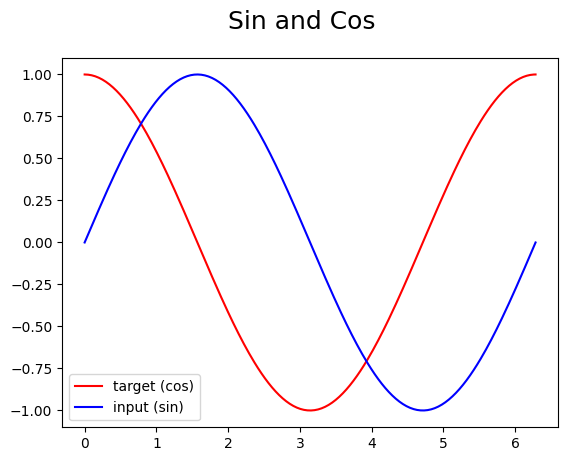

In [5]:
plt.figure(1)
plt.suptitle('Sin and Cos',fontsize='18')
plt.plot(steps, y_np, 'r-', label='target (cos)')
plt.plot(steps, x_np, 'b-', label='input (sin)')
plt.legend(loc='best')
plt.show()

下面定义一下我们的网络结构

In [11]:
class RNN(nn.Module):
    def __init__(self):
        super(RNN, self).__init__()
        self.rnn = nn.RNN(
        input_size=INPUT_SIZE,
        hidden_size=H_SIZE, 
        num_layers=1, 
        batch_first=True,
        )
        self.out = nn.Linear(H_SIZE, 1)
    def forward(self, x, h_state):
        # x (batch, time_step, input_size)
        # h_state (num_layers, batch, hidden_size) 最后一个时间步的隐藏状态。（可作为下一次序列输入的初始隐藏状态）
        # r_out (batch, time_step, hidden_size)

        # RNN前向传播：输入x和初始隐藏状态h_state，输出所有时间步的隐藏状态+最后隐藏状态
        # r_out：所有时间步的隐藏状态，形状(batch, time_step, H_SIZE)（因为batch_first=True）；
        # h_state：最后一个时间步的隐藏状态，形状(num_layers, batch, H_SIZE)（可作为下一次序列输入的初始隐藏状态）。
        r_out, h_state = self.rnn(x, h_state)
        # print('r_out',r_out.size, r_out)
        # print('h_state',h_state.data, h_state)
        outs = [] # 保存所有的预测值
        # torch.Tensor.size(dim)  省略dim参数（如r_out.size()），会返回一个tuple，包含所有维度的长度
        for time_step in range(r_out.size(1)): # 计算每一步长的预测值
            # r_out[:, time_step, :]：取出所有样本在time_step这个时间步的隐藏状态，形状从(batch, time_step, H_SIZE)变为(batch, H_SIZE)；
            # outs 多个 (H_SIZE, 1)
            outs.append(self.out(r_out[:, time_step, :]))
        # torch.stack是将多个形状相同的张量沿指定维度堆叠成一个新张量，参数dim=1表示沿 “时间步维度” 堆叠：
        #如输入：10 个(8,1)的张量；堆叠后：(8, 10, 1)（batch=8，time_step=10，output=1）；
        return torch.stack(outs, dim=1), h_state
         # 也可使用以下这样的返回值
         # 这个操作的本质是：将 “批次 + 时间步” 两个维度合并成一个维度，把所有时间步的隐藏状态 “平铺” 成二维张量，方便全连接层一次性处理。
         # r_out = r_out.view(-1, H_SIZE)
         # outs = self.out(r_out)
         # return outs, h_state

下面我们定义我们的网络

In [13]:
rnn = RNN().to(DEVICE)
optimizer = torch.optim.Adam(rnn.parameters()) # Adam优化，几乎不用调参
criterion = nn.MSELoss() # 因为最终的结果是一个数值，所以损失函数用均方误差

由于没有测试集，所以我们训练和测试写在一起了

In [8]:
for step in range(2):
    print(step)
testzw1=torch.ones(1).data
testzw2=torch.ones(1).cpu()

0
1


prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
EPOCHS: 19,Loss:0.002524
prediction shape: torch.Size([1, 10, 1])
prediction_flatten shape: (10,)


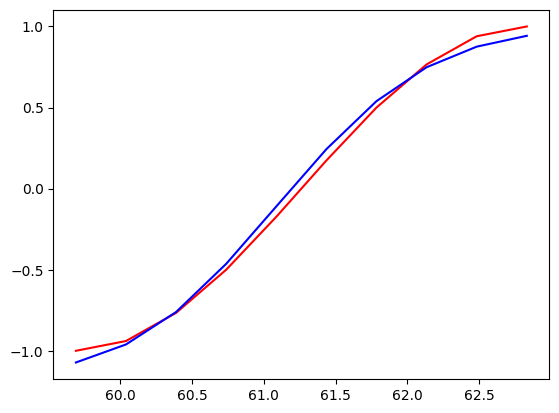

prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
EPOCHS: 39,Loss:0.002935
prediction shape: torch.Size([1, 10, 1])
prediction_flatten shape: (10,)


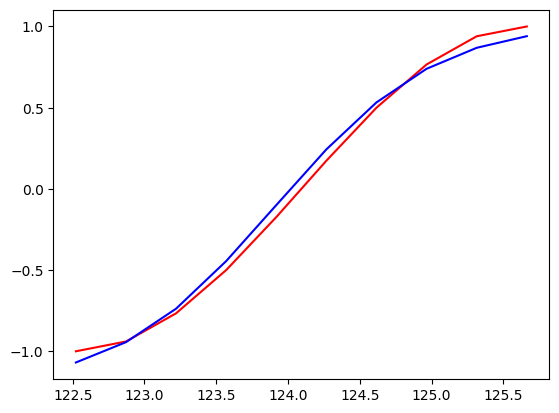

prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
EPOCHS: 59,Loss:0.003107
prediction shape: torch.Size([1, 10, 1])
prediction_flatten shape: (10,)


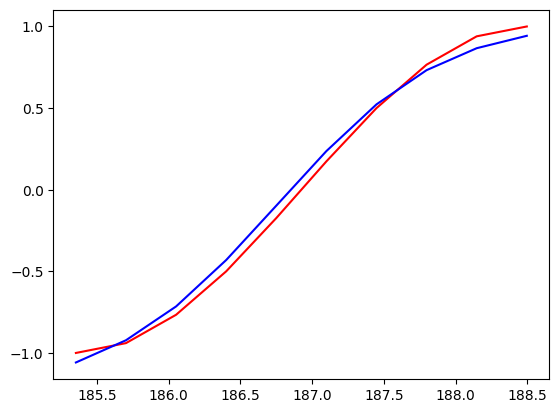

prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
EPOCHS: 79,Loss:0.003083
prediction shape: torch.Size([1, 10, 1])
prediction_flatten shape: (10,)


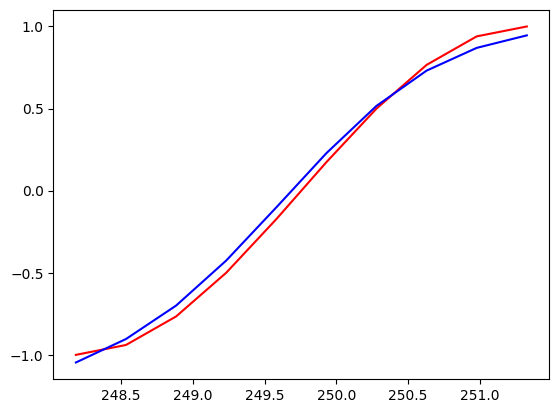

prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
EPOCHS: 99,Loss:0.002762
prediction shape: torch.Size([1, 10, 1])
prediction_flatten shape: (10,)


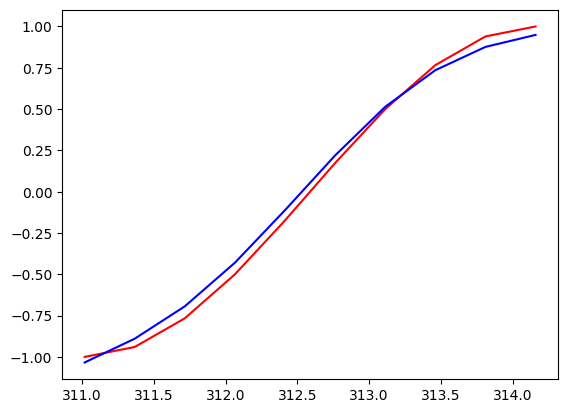

prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
EPOCHS: 119,Loss:0.002152
prediction shape: torch.Size([1, 10, 1])
prediction_flatten shape: (10,)


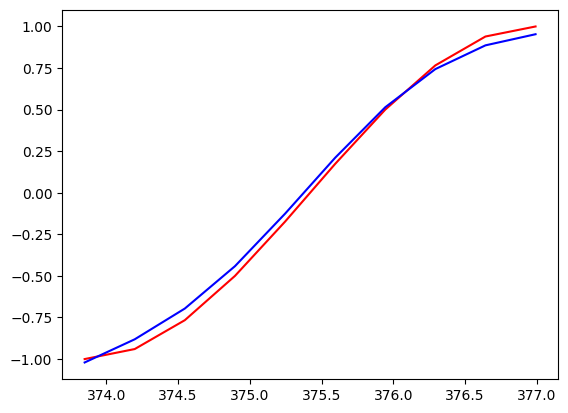

prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
EPOCHS: 139,Loss:0.001462
prediction shape: torch.Size([1, 10, 1])
prediction_flatten shape: (10,)


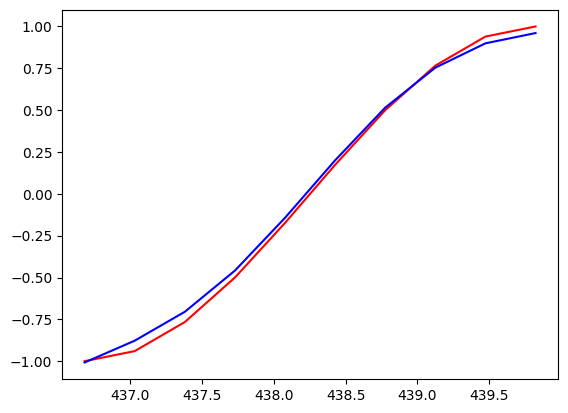

prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
EPOCHS: 159,Loss:0.000945
prediction shape: torch.Size([1, 10, 1])
prediction_flatten shape: (10,)


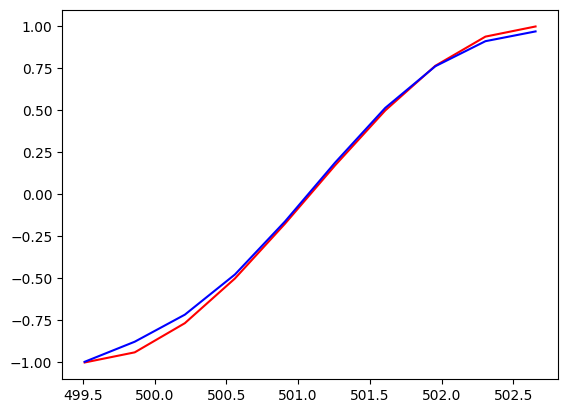

prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
EPOCHS: 179,Loss:0.000705
prediction shape: torch.Size([1, 10, 1])
prediction_flatten shape: (10,)


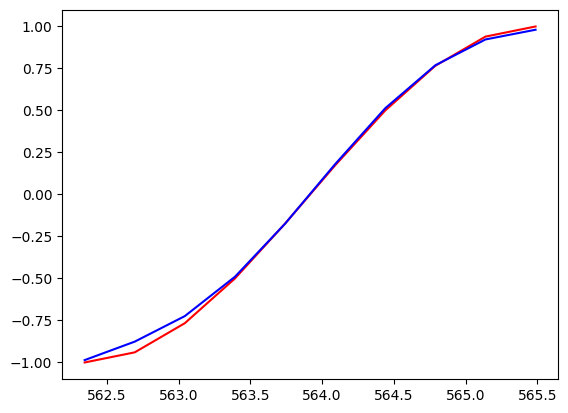

prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
EPOCHS: 199,Loss:0.000658
prediction shape: torch.Size([1, 10, 1])
prediction_flatten shape: (10,)


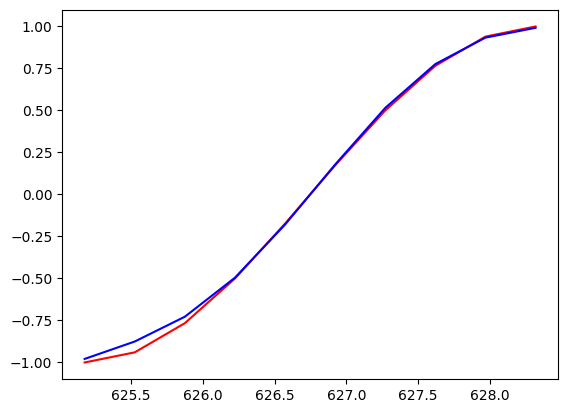

prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
EPOCHS: 219,Loss:0.005209
prediction shape: torch.Size([1, 10, 1])
prediction_flatten shape: (10,)


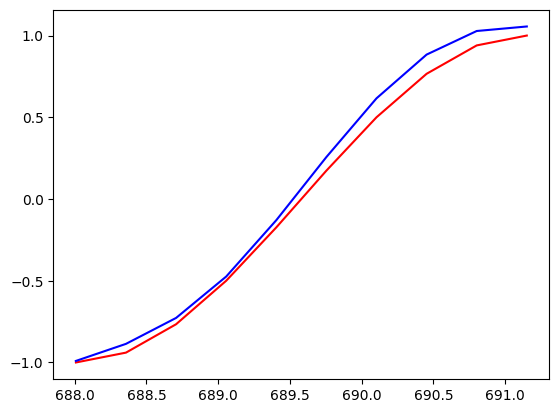

prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
EPOCHS: 239,Loss:0.105333
prediction shape: torch.Size([1, 10, 1])
prediction_flatten shape: (10,)


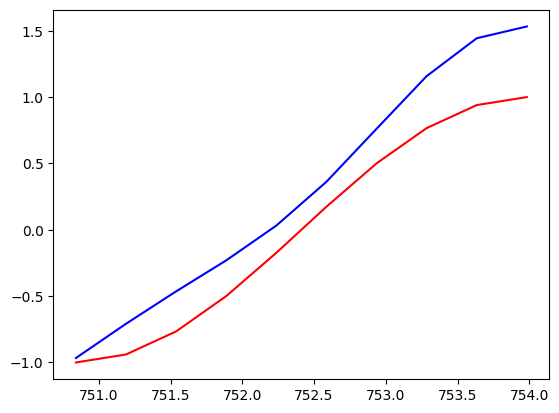

prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
EPOCHS: 259,Loss:0.013990
prediction shape: torch.Size([1, 10, 1])
prediction_flatten shape: (10,)


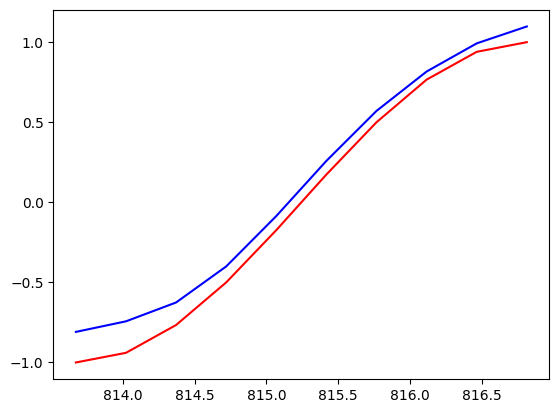

prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
EPOCHS: 279,Loss:0.008848
prediction shape: torch.Size([1, 10, 1])
prediction_flatten shape: (10,)


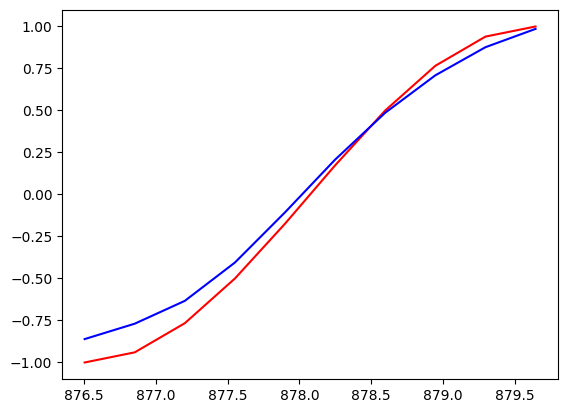

prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
prediction.shape: torch.Size([1, 10, 1])
EPOCHS: 299,Loss:0.009874
prediction shape: torch.Size([1, 10, 1])
prediction_flatten shape: (10,)


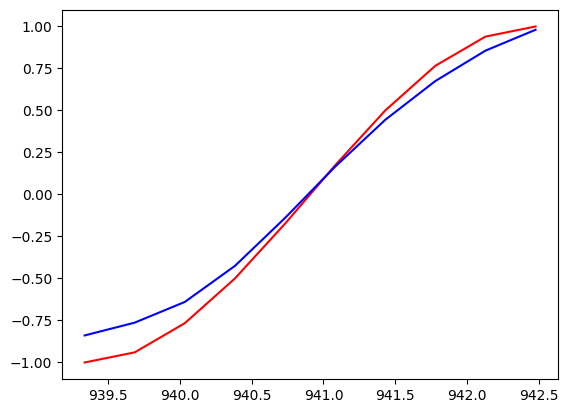

In [17]:
rnn.train()
plt.figure(2)
for step in range(EPOCHS):
    start, end = step * np.pi, (step+1)*np.pi # 一个时间周期
    steps = np.linspace(start, end, TIME_STEP, dtype=np.float32)
    x_np = np.sin(steps)
    # print('x_np.shape:',x_np.shape) # (10,)
    y_np = np.cos(steps)
    # (10,) 变为 (1, 10, 1)
    # np.newaxis：在指定位置增加一个维度，维度大小为 1,等价于 None
    x = torch.from_numpy(x_np[np.newaxis, :, np.newaxis]) # shape (batch, time_step, input_size)
    y = torch.from_numpy(y_np[np.newaxis, :, np.newaxis]) # (1, 10, 1)
    x=x.to(DEVICE)
    # h_state 的初始值必须设为 None，这是 PyTorch RNN 的标准调用方式，模型会自动初始化全 0 隐藏状态
    prediction, h_state = rnn(x, h_state) # rnn output
    # print('prediction.shape:',prediction.shape) # torch.Size([1, 10, 1])
    # 这一步非常重要
    # h_state数据类型为torch.Tensor   requires_grad=False（不再追踪梯度）
    h_state = h_state.data # 重置隐藏层的状态, 切断和前一次迭代的链接
    loss = criterion(prediction.cpu(), y) 
    # 这三行写在一起就可以
    optimizer.zero_grad() 
    loss.backward() 
    optimizer.step() 
    if (step+1)%20==0: #每训练20个批次可视化一下效果，并打印一下loss
        print("EPOCHS: {},Loss:{:4f}".format(step,loss))
        plt.plot(steps, y_np.flatten(), 'r-')
        print('prediction shape:',prediction.shape)  # torch.Size([1, 10, 1])
        prediction_flatten= prediction.cpu().data.numpy().flatten()
        print('prediction_flatten shape:',prediction_flatten.shape) # prediction_flatten shape: (10,)
        plt.plot(steps, prediction_flatten, 'b-')
        plt.draw()
        plt.pause(0.01)


蓝色是模型预测的结果，红色是函数的结果，通过300次的训练，已经基本拟合了